In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import contextily as ctx

from glob import glob

import warnings
warnings.filterwarnings('ignore')

data_dir = '/Users/jcolen/Documents/chkd_toy_problem/data'

,Total Population,Population 0-19,geometry
ZCTA5CE20,,,
27818,1159,204,"POLYGON ((-77.16438 36.54633, -77.16432 36.546..."
27950,1918,394,"POLYGON ((-76.15427 36.54023, -76.15387 36.540..."
23128,707,126,"MULTIPOLYGON (((-76.45022 37.43022, -76.45002 ..."
23314,9523,2452,"POLYGON ((-76.58686 36.93857, -76.58619 36.938..."
23462,68045,16615,"POLYGON ((-76.19498 36.83293, -76.19495 36.833..."
...,...,...,...
23878,1162,277,"POLYGON ((-77.09782 36.86998, -77.09421 36.871..."
23668,739,497,"POLYGON ((-76.34185 37.02094, -76.34181 37.021..."
23667,80,8,"POLYGON ((-76.33635 37.02244, -76.33578 37.022..."


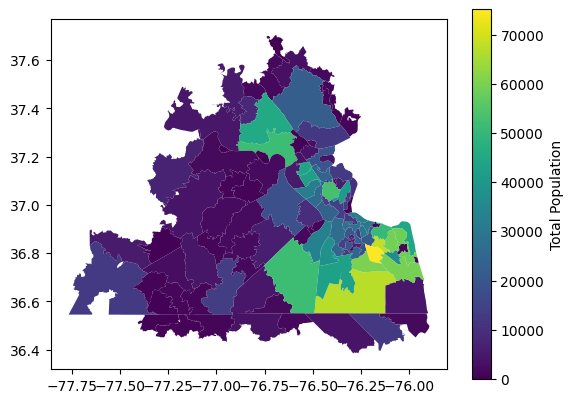

In [2]:
zcta_df = gpd.read_file(f'{data_dir}/Hampton_Roads_ZCTA_Populations/Hampton_Roads_ZCTA_Populations.shp') \
    .rename({
        'Total Popu': 'Total Population',
        'Population': 'Population 0-19',
    }, axis=1) \
    .set_index('ZCTA5CE20')
zcta_df.plot(column='Total Population', legend=True, legend_kwds=dict(label="Total Population"))
zcta_df

# Load the weather data

In [118]:
hourly_columns = [
    'HourlyAltimeterSetting',
    'HourlyDewPointTemperature',
    'HourlyDryBulbTemperature',
    # 'HourlyPrecipitation', # Defer to Daily
    # 'HourlyPresentWeatherType', # String code
    'HourlyPressureChange',
    'HourlyPressureTendency',
    'HourlyRelativeHumidity',
    # 'HourlySkyConditions', # String code
    'HourlySeaLevelPressure',
    'HourlyStationPressure',
    'HourlyVisibility',
    'HourlyWetBulbTemperature',
    # 'HourlyWindDirection', # Often not recorded, hard to average
    'HourlyWindGustSpeed',
    'HourlyWindSpeed',
    'DailyPrecipitation',
]

def load_csv_to_gpd(path, hourly_columns=hourly_columns):
    #weather_df = pd.read_csv(f'{data_dir}/NOAA_local_climatological_data_v2/LCD_USW00003739_2018.csv')
    weather_df = pd.read_csv(path)

    # Convert to datetime object
    weather_df['date_local'] = pd.to_datetime(weather_df['DATE']).dt.to_period('D')
    weather_df = weather_df.set_index(['date_local', 'STATION'])

    # Get daily averages from hourly measurements
    hourly_df = weather_df.loc[:, hourly_columns] \
            .dropna(how='all', axis=0) \
            .dropna(how='all', axis=1)
    for col in hourly_df:
        hourly_df[col] = hourly_df[col].replace({'T': 0.0,})
        hourly_df[col] = pd.to_numeric(hourly_df[col], errors='coerce')

    # Some humidity measurements are wrong
    hourly_df.loc[hourly_df['HourlyRelativeHumidity'] > 110, 'HourlyRelativeHumidity'] = np.nan
    
    daily_df = hourly_df.groupby(['date_local', 'STATION']).agg('mean')

    # Only include precipitation if we have a daily measurement, as the hourly measurements are suspect
    if 'DailyPrecipitation' in hourly_df.columns:
        daily_df['TotalPrecipitation'] = hourly_df.groupby(['date_local', 'STATION']).agg({'DailyPrecipitation': 'mean'})

    # Get station location
    station_df = weather_df.groupby('STATION').agg({'LATITUDE': 'first', 'LONGITUDE': 'first'})
    station_df = gpd.GeoDataFrame(station_df, geometry=gpd.points_from_xy(station_df['LONGITUDE'], station_df['LATITUDE']))

    daily_df = station_df.merge(daily_df, left_index=True, right_index=True, how='right').drop(['LATITUDE', 'LONGITUDE'], axis=1)

    return daily_df

paths = sorted(glob(f'{data_dir}/NOAA_local_climatological_data_v2/LCD_*.csv'))

daily_df = []
for path in paths:
    if '03739' in path: continue # Skip Cape Charles
    # if '00154' in path: continue # Skip Hampton Roads Executive Airport, shows a lot of spurious precipitation data
    # if '93735_2018' in path: continue # Skip Fort Eustis Felker Army Air Field for 2018, shows a lot of spurious precipitation data
    try:
        daily_df.append(load_csv_to_gpd(path))
    except Exception as e:
        print(f'Could not load {path}:', e)

daily_df = pd.concat(daily_df, axis=0)
daily_df = daily_df.swaplevel(0,1).sort_index()
daily_df.geometry = daily_df.geometry.set_crs('EPSG:4326')

daily_df

geometry  HourlyAltimeterSetting  \
STATION     date_local                                                     
USW00000154 2018-01-01     POINT (-76.45 36.783)             1032.160870   
            2018-01-02     POINT (-76.45 36.783)             1034.020833   
            2018-01-03     POINT (-76.45 36.783)             1019.403226   
            2018-01-04     POINT (-76.45 36.783)             1005.113462   
            2018-01-05     POINT (-76.45 36.783)             1021.704167   
...                                          ...                     ...   
USW00093773 2023-12-27  POINT (-77.0012 36.9827)             1010.869565   
            2023-12-28  POINT (-77.0012 36.9827)             1007.343103   
            2023-12-29  POINT (-77.0012 36.9827)             1007.912069   
            2023-12-30  POINT (-77.0012 36.9827)             1011.425806   
            2023-12-31  POINT (-77.0012 36.9827)             1017.395833   

                        HourlyDewPointTemperature  HourlyDryBulbTemperature  \
STATION     date_local                                                        
USW00000154 2018-01-01                 -15.191304                 -7.965217   
            2018-01-02                 -15.720833                 -8.300000   
            2018-01-03                  -7.900000                 -4.119355   
            2018-01-04                  -6.782692                 -3.330769   
            2018-01-05                 -17.329167                 -8.325000   
...                                           ...                       ...   
USW00093773 2023-12-27                  13.900000                 14.750725   
            2023-12-28                  10.227586                 11.363793   
            2023-12-29                   5.306897                  6.162069   
            2023-12-30                   1.158065                  4.674194   
            2023-12-31                  -0.937500                  2.908333   

                        HourlyPressureChange  HourlyPressureTendency  \
STATION     date_local                                                 
USW00000154 2018-01-01                0.5250                   2.750   
            2018-01-02               -0.1875                   4.125   
            2018-01-03               -1.4000                   7.250   
            2018-01-04                2.9000                   4.250   
            2018-01-05                1.7000                   2.250   
...                                      ...                     ...   
USW00093773 2023-12-27               -1.4375                   6.875   
            2023-12-28                0.3000                   4.500   
            2023-12-29               -0.1750                   4.625   
            2023-12-30                0.9625                   2.625   
            2023-12-31                0.3500                   2.750   

                        HourlyRelativeHumidity  HourlySeaLevelPressure  \
STATION     date_local                                                   
USW00000154 2018-01-01               58.652174             1032.300000   
            2018-01-02               58.958333             1034.208333   
            2018-01-03               77.354839             1022.004167   
            2018-01-04               78.442308             1006.569565   
            2018-01-05               50.250000             1021.858333   
...                                        ...                     ...   
USW00093773 2023-12-27               94.768116             1011.329167   
            2023-12-28               93.051724             1007.308333   
            2023-12-29               94.586207             1007.583333   
            2023-12-30               80.129032             1011.970833   
            2023-12-31               78.583333             1017.562500   

                        HourlyStationPressure  HourlyVisibility  \
STATION     date_local                                  

<Axes: >

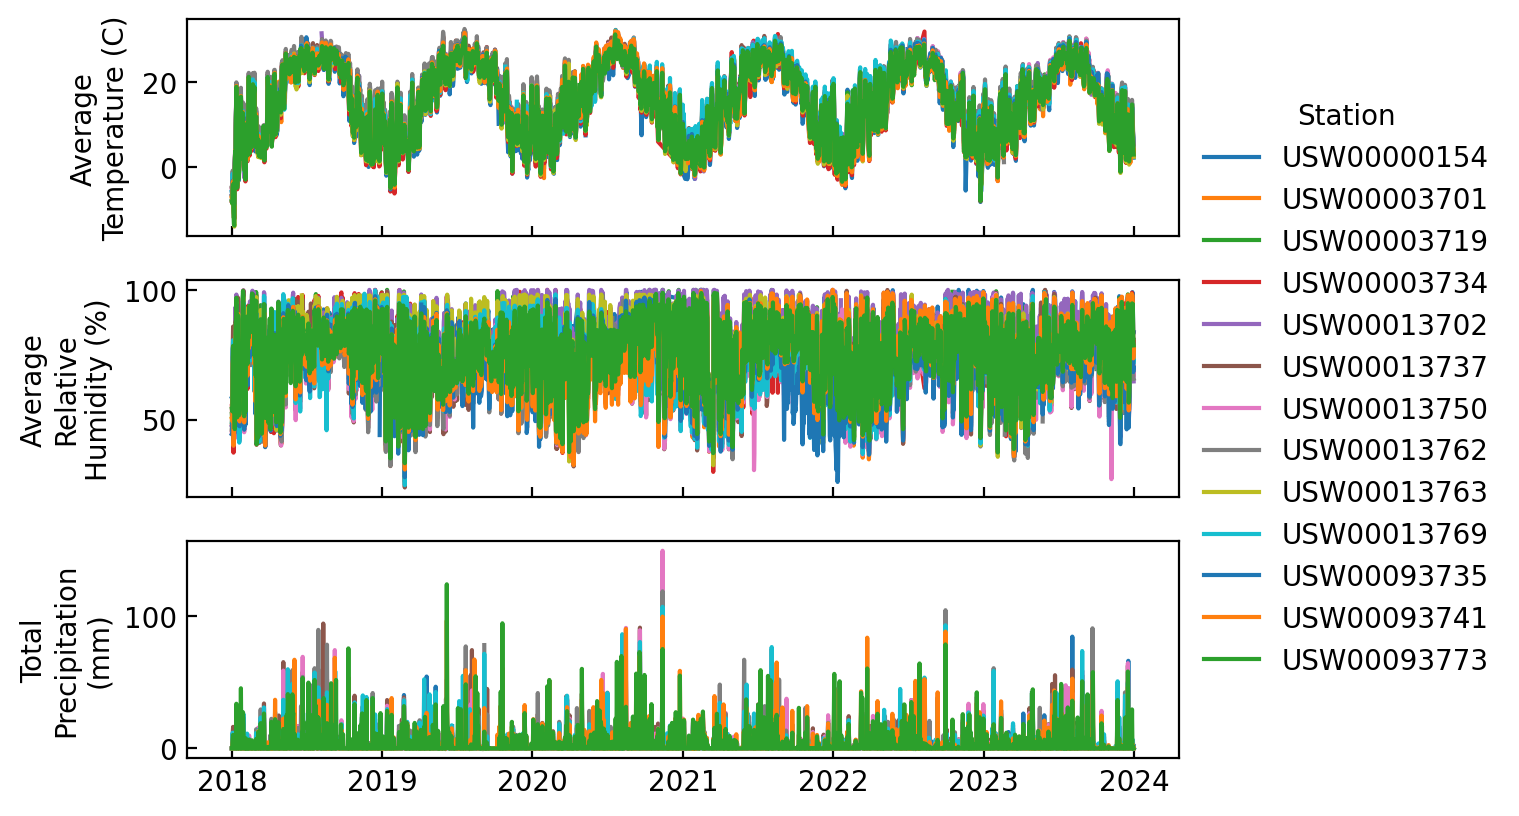

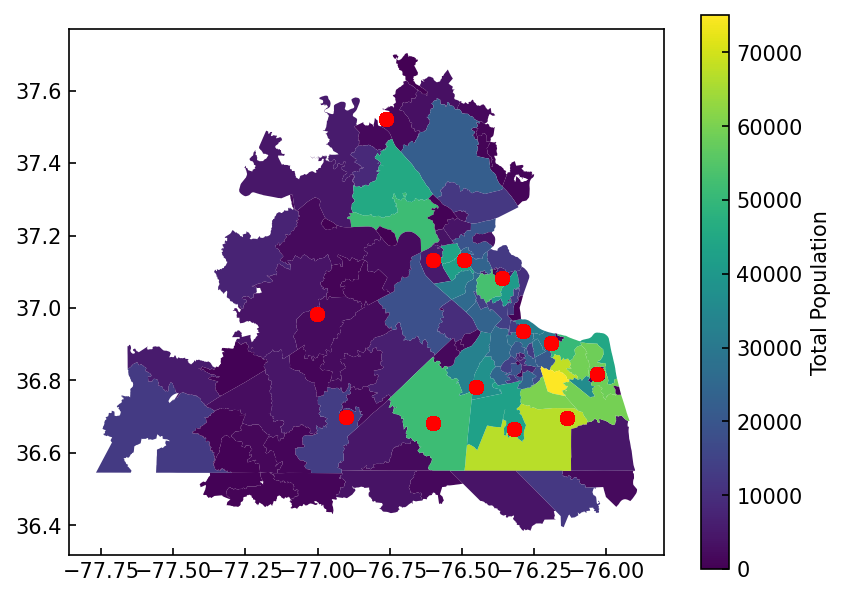

In [119]:
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

fig, ax = plt.subplots(3, 1, dpi=200, sharex=True)
for station in daily_df.index.get_level_values(0).unique():
    station_df = daily_df.loc[station]
    ax[0].plot(station_df.index.to_timestamp(), station_df.HourlyDryBulbTemperature, label=station)
    ax[1].plot(station_df.index.to_timestamp(), station_df.HourlyRelativeHumidity, label=station)
    ax[2].plot(station_df.index.to_timestamp(), station_df.TotalPrecipitation, label=station)

ax[0].set(ylabel='Average\nTemperature (C)')
ax[1].set(ylabel='Average\nRelative\nHumidity (%)')
ax[2].set(ylabel='Total\nPrecipitation\n(mm)')

ax[1].legend(title='Station', loc='center left', bbox_to_anchor=[1, 0.5], framealpha=0.)

fig, ax = plt.subplots(1, 1, dpi=150)
zcta_df.plot(ax=ax, column='Total Population', legend=True, legend_kwds=dict(label="Total Population"))

daily_df = daily_df.to_crs(zcta_df.crs)

daily_df.plot(ax=ax, color='red')

In [120]:
daily_df['TotalPrecipitation'].describe()

count    14134.000000
mean         3.292246
std          9.305891
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max        149.600000
Name: TotalPrecipitation, dtype: float64

  0%|          | 0/2191 [00:00<?, ?it/s]

geometry  \
date_local ZCTA5CE20                                                      
2018-01-01 23011      POLYGON ((-76.87403 37.50098, -76.87318 37.501...   
           23030      POLYGON ((-77.27158 37.32656, -77.2679 37.3369...   
           23032      POLYGON ((-76.73979 37.69841, -76.7391 37.6984...   
           23050      POLYGON ((-76.45234 37.49712, -76.45229 37.497...   
           23056      POLYGON ((-76.41509 37.44044, -76.41498 37.440...   
...                                                                 ...   
2023-12-31 27926      POLYGON ((-76.68527 36.50472, -76.68516 36.504...   
           27937      POLYGON ((-76.93636 36.48014, -76.93634 36.480...   
           27950      POLYGON ((-76.15427 36.54023, -76.15387 36.540...   
           27958      MULTIPOLYGON (((-76.02909 36.46714, -76.02689 ...   
           27976      POLYGON ((-76.54197 36.55065, -76.54161 36.550...   

                      HourlyDryBulbTemperature  HourlyRelativeHumidity  \
date_local ZCTA5CE20                                                     
2018-01-01 23011                     -8.006298               54.550518   
           23030                     -8.203385               54.464163   
           23032                     -7.936523               54.526708   
           23050                     -7.234309               50.993580   
           23056                     -7.061629               49.992240   
...                                        ...                     ...   
2023-12-31 27926                      2.907788               80.051739   
           27937                      2.690890               79.180481   
           27950                      4.475408               70.155803   
           27958                      3.883098               72.238138   
           27976                      3.008545               77.401569   

                      HourlyStationPressure  HourlyWindSpeed  \
date_local ZCTA5CE20                                           
2018-01-01 23011                1031.706217         2.090745   
           23030                1030.250944         1.881263   
           23032                1031.977023         2.476587   
           23050                1031.393913         3.790522   
           23056                1031.154719         4.148575   
...                                     ...              ...   
2023-12-31 27926                1015.810503         0.464002   
           27937                1015.931110         0.463224   
           27950                1016.702730         0.832646   
           27958                1016.709788         0.410152   
           27976                1016.460438         0.280111   

                      TotalPrecipitation  
date_local ZCTA5CE20                      
2018-01-01 23011                     0.0  
           23030                     0.0  
           23032                     0.0  
           23050                     0.0  
           23056                     0.0  
...                                  ...  
2023-12-31 27926                     1.8  
           27937                     1.8  
           27950                     0.0  
           27958                     0.0  
           27976                     0.0  

[267302 rows x 6 columns]

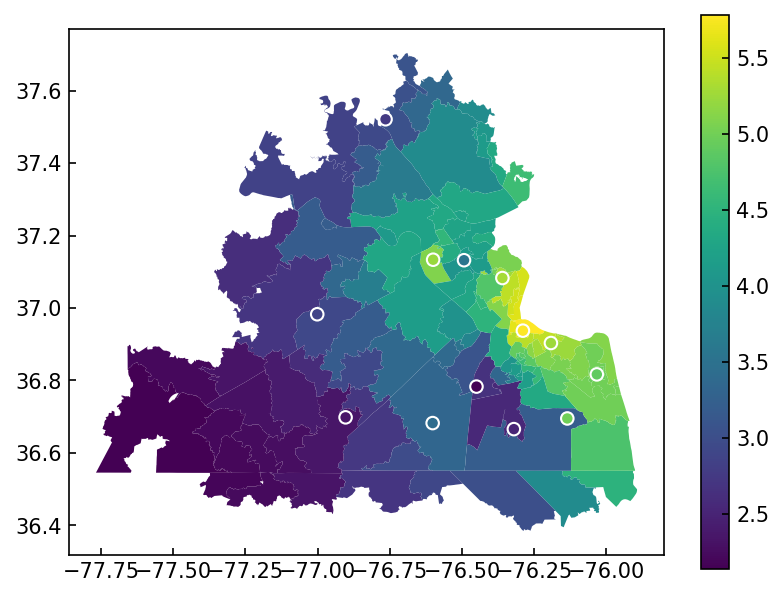

In [134]:
from scipy.interpolate import RBFInterpolator, NearestNDInterpolator
from tqdm.auto import tqdm

def nnd_interpolate(data, regions, column='sample_measurement'):
    """ Interpolate source data to target points using Nearest Neighbors interpolation
    """
    assert data.crs == regions.crs

    # Target points 
    centroids = regions.to_crs('+proj=cea').centroid.to_crs(regions.crs)
    centroids = np.array([(point.x, point.y) for point in centroids])

    # Determine measurement points in the data
    points = np.array([(point.x, point.y) for point in data.geometry])

    # Perform RBF interpolation
    nnd = NearestNDInterpolator(points, data[column])
    interpolated = nnd(centroids)
    return interpolated

def rbf_interpolate(data, regions, column='sample_measurement', kernel='linear'):
    """ Interpolate source data to target points using RBF interpolation
    """
    assert data.crs == regions.crs

    # Target points 
    centroids = regions.to_crs('+proj=cea').centroid.to_crs(regions.crs)
    centroids = np.array([(point.x, point.y) for point in centroids])

    # Determine measurement points in the data
    points = np.array([(point.x, point.y) for point in data.geometry])

    # Perform RBF interpolation
    rbf = RBFInterpolator(points, data[column], kernel=kernel)
    interpolated = rbf(centroids)
    return interpolated

zcta_measurements = []
rbf_columns = ['HourlyDryBulbTemperature', 'HourlyRelativeHumidity', 'HourlyStationPressure', 'HourlyWindSpeed']
nnd_columns = ['TotalPrecipitation']


daily_df.index = daily_df.index.reorder_levels(order=['date_local', 'STATION'])
daily_df = daily_df.sort_index()

for date_local in tqdm(daily_df.index.get_level_values(0).unique()):
    daily_measurements = daily_df.loc[[date_local]]

    daily_zcta = zcta_df.loc[:, ['geometry']].copy()
    for column in rbf_columns:
        daily_zcta[column] = rbf_interpolate(daily_measurements.dropna(subset=column), zcta_df, column=column)
    for column in nnd_columns:
        daily_zcta[column] = nnd_interpolate(daily_measurements.dropna(subset=column), zcta_df, column=column)

    daily_zcta['date_local'] = date_local

    zcta_measurements.append(daily_zcta)

fig, ax = plt.subplots(1, 1, dpi=150)
daily_zcta.plot(column='HourlyDryBulbTemperature', ax=ax, legend=True)
daily_measurements.plot(column='HourlyDryBulbTemperature', ax=ax, edgecolor='white')

zcta_measurements = pd.concat(zcta_measurements, axis=0).reset_index().set_index(['date_local', 'ZCTA5CE20']).sort_index()
zcta_measurements

In [138]:
to_save = zcta_measurements.drop('geometry', axis=1).rename({
    'HourlyDryBulbTemperature': 'AverageDryBulbTemperature',
    'HourlyRelativeHumidity': 'AverageRelativeHumidity',
    'HourlyStationPressure': 'AverageStationPressure',
    'HourlyWindSpeed': 'AverageWindSpeed',
}, axis=1)

to_save.to_csv(f'{data_dir}/zcta_daily_weather.csv')
to_save

AverageDryBulbTemperature  AverageRelativeHumidity  \
date_local ZCTA5CE20                                                       
2018-01-01 23011                      -8.006298                54.550518   
           23030                      -8.203385                54.464163   
           23032                      -7.936523                54.526708   
           23050                      -7.234309                50.993580   
           23056                      -7.061629                49.992240   
...                                         ...                      ...   
2023-12-31 27926                       2.907788                80.051739   
           27937                       2.690890                79.180481   
           27950                       4.475408                70.155803   
           27958                       3.883098                72.238138   
           27976                       3.008545                77.401569   

                      AverageStationPressure  AverageWindSpeed  \
date_local ZCTA5CE20                                             
2018-01-01 23011                 1031.706217          2.090745   
           23030                 1030.250944          1.881263   
           23032                 1031.977023          2.476587   
           23050                 1031.393913          3.790522   
           23056                 1031.154719          4.148575   
...                                      ...               ...   
2023-12-31 27926                 1015.810503          0.464002   
           27937                 1015.931110          0.463224   
           27950                 1016.702730          0.832646   
           27958                 1016.709788          0.410152   
           27976                 1016.460438          0.280111   

                      TotalPrecipitation  
date_local ZCTA5CE20                      
2018-01-01 23011                     0.0  
           23030                     0.0  
           23032                     0.0  
           23050                     0.0  
           23056                     0.0  
...                                  ...  
2023-12-31 27926                     1.8  
           27937                     1.8  
           27950                     0.0  
           27958                     0.0  
           27976                     0.0  

[267302 rows x 5 columns]

# Sample testing

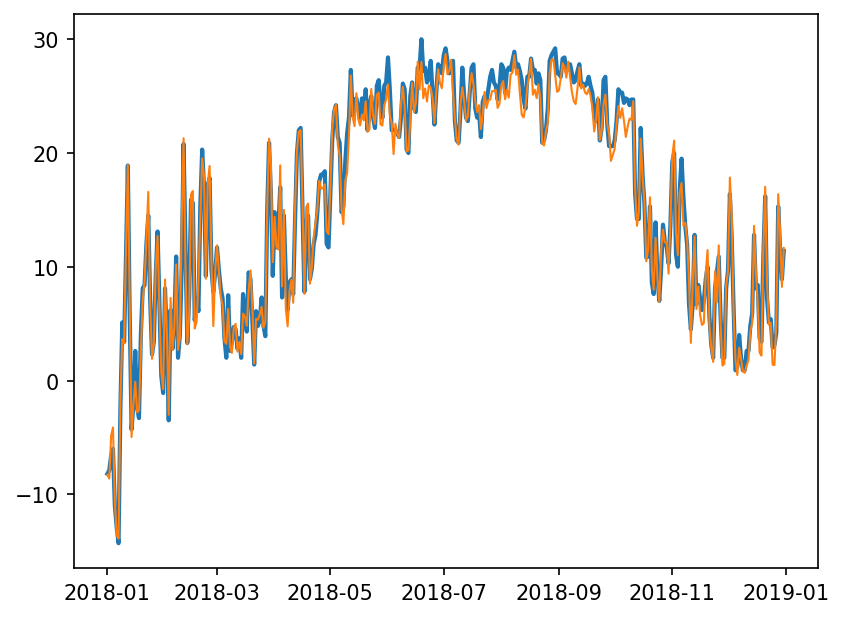

In [158]:
weather_df = pd.read_csv(f'{data_dir}/NOAA_local_climatological_data_v2/LCD_USW00093773_2018.csv')
weather_df['date_local'] = pd.to_datetime(weather_df['DATE']).dt.to_period('D')
weather_df = weather_df.set_index(['date_local', 'STATION'])

weather_df.head()

# Get daily averages
daily_values = weather_df.filter(like='Daily').dropna(how='all', axis=0).dropna(how='all', axis=1)

# Get daily averages from hourly measurements
hourly_df = weather_df.loc[:, hourly_columns] \
        .dropna(how='all', axis=0) \
        .dropna(how='all', axis=1)
for col in hourly_df:
    hourly_df[col] = hourly_df[col].replace({'T': 0.0,})
    hourly_df[col] = pd.to_numeric(hourly_df[col], errors='coerce')
daily_df = hourly_df.groupby(['date_local', 'STATION']).agg('mean')

fig, ax = plt.subplots(1,1,dpi=150)
ax.plot(daily_values.index.get_level_values(0).to_timestamp(), daily_values['DailyAverageDryBulbTemperature'].values, linewidth=2)
ax.plot(daily_df.index.get_level_values(0).to_timestamp(), daily_df['HourlyDryBulbTemperature'].values, linewidth=1)

In [117]:
weather_df.filter(like='Hourly').dtypes

HourlyAltimeterSetting       float64
HourlyDewPointTemperature    float64
HourlyDryBulbTemperature     float64
HourlyPrecipitation          float64
HourlyPresentWeatherType      object
HourlyPressureChange         float64
HourlyPressureTendency       float64
HourlyRelativeHumidity       float64
HourlySkyConditions           object
HourlySeaLevelPressure       float64
HourlyStationPressure        float64
HourlyVisibility              object
HourlyWetBulbTemperature     float64
HourlyWindDirection           object
HourlyWindGustSpeed          float64
HourlyWindSpeed               object
dtype: object